<a href="https://colab.research.google.com/github/sgagana-19/sales-project/blob/main/sales_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files

uploaded = files.upload

Saving SQL_Sales_Dataset_200_Rows.xlsx to SQL_Sales_Dataset_200_Rows.xlsx


In [3]:
import pandas as pd

df = pd.read_excel("SQL_Sales_Dataset_200_Rows.xlsx")

df.head()

,order_id,customer_name,order_date,category,sub_category,product_name,quantity,unit_price,total_price,region
0,1000,Caleb Davis,2025-01-31,Clothing,Jeans,Jeans Try,2,1197,2394,West
1,1001,Misty Herrera,2025-05-05,Clothing,Jeans,Jeans New,9,1509,13581,South
2,1002,Rick Soto,2025-06-09,Clothing,Shoes,Shoes Us,5,1046,5230,East
3,1003,Sean Haas,2025-02-27,Furniture,Desk,Desk Section,10,292,2920,South
4,1004,Ann Hall,2025-06-01,Furniture,Cabinet,Cabinet Center,2,548,1096,North


In [5]:
print("Shape of dataset:")
print(df.shape)

print("\nColumn names:")
print(df.columns)

print("\nDataset information:")
df.info()

print("\nStatistical summary:")
df.describe()

Shape of dataset:
(200, 10)

Column names:
Index(['order_id', 'customer_name', 'order_date', 'category', 'sub_category',
       'product_name', 'quantity', 'unit_price', 'total_price', 'region'],
      dtype='object')

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       200 non-null    int64         
 1   customer_name  200 non-null    object        
 2   order_date     200 non-null    datetime64[ns]
 3   category       200 non-null    object        
 4   sub_category   200 non-null    object        
 5   product_name   200 non-null    object        
 6   quantity       200 non-null    int64         
 7   unit_price     200 non-null    int64         
 8   total_price    200 non-null    int64         
 9   region         200 non-null    object        
dtypes: datetime64[ns](1), int64(4), object

,order_id,order_date,quantity,unit_price,total_price
count,200.000000,200,200.000000,200.000000,200.000000
mean,1099.500000,2025-03-27 22:33:36,4.910000,2421.495000,12100.535000
min,1000.000000,2024-12-24 00:00:00,1.000000,79.000000,79.000000
25%,1049.750000,2025-02-14 00:00:00,2.000000,1120.000000,3060.000000
50%,1099.500000,2025-03-28 12:00:00,5.000000,2373.500000,8912.000000
75%,1149.250000,2025-05-09 00:00:00,7.000000,3541.750000,19350.750000
max,1199.000000,2025-06-24 00:00:00,10.000000,4997.000000,47940.000000
std,57.879185,NaN,3.017853,1464.016187,10915.548067


In [7]:
numeric_columns = df.select_dtypes(include="number").columns

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

In [8]:
categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [9]:
df.isnull().sum()
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [10]:
df = df.drop_duplicates()
print("Duplicate rows after cleaning:", df.duplicated().sum())

Duplicate rows after cleaning: 0


In [11]:
category_revenue = df.groupby("category")["total_price"].sum()

print(category_revenue)

category
Clothing       484259
Electronics    549302
Furniture      714399
Grocery        672147
Name: total_price, dtype: int64


In [12]:
category_revenue.sort_values(ascending=False)

,total_price
category,
Furniture,714399
Grocery,672147
Electronics,549302
Clothing,484259


In [15]:
df["total_price"] = df["quantity"] * df["unit_price"]
df.groupby("category")["total_price"].sum().sort_values(ascending=False)

,total_price
category,
Furniture,714399
Grocery,672147
Electronics,549302
Clothing,484259


In [16]:
sorted_df = df.sort_values(
    by=["category", "total_price"],
    ascending=[True, False]
)

sorted_df.head(20)

,order_id,customer_name,order_date,category,sub_category,product_name,quantity,unit_price,total_price,region
168,1168,Megan Charles,2025-03-26,Clothing,Jeans,Jeans Card,10,4462,44620,West
59,1059,Miss Rebecca Levine,2025-02-28,Clothing,Shirt,Shirt Look,6,4794,28764,East
157,1157,Patricia Gill,2025-03-23,Clothing,Jacket,Jacket Song,7,3915,27405,East
180,1180,Hailey Cobb,2025-02-19,Clothing,Jacket,Jacket Heart,6,4285,25710,East
82,1082,Kenneth Lee,2025-05-06,Clothing,Jacket,Jacket Realize,7,3486,24402,West
42,1042,David Norris,2025-06-10,Clothing,Shoes,Shoes Far,7,3445,24115,South
171,1171,David Dominguez,2025-03-06,Clothing,Shoes,Shoes Each,8,2902,23216,South
128,1128,Gregory Miller,2025-02-21,Clothing,Jacket,Jacket Image,8,2822,22576,South
62,1062,Jessica Hernandez,2025-05-21,Clothing,Shoes,Shoes Care,7,3208,22456,East
99,1099,Amanda Reeves,2025-04-21,Clothing,Jeans,Jeans Family,5,4419,22095,South


In [17]:
numerical_data = df.select_dtypes(include="number")

correlation_matrix = numerical_data.corr()

correlation_matrix

,order_id,quantity,unit_price,total_price
order_id,1.000000,-0.018182,0.102267,0.099480
quantity,-0.018182,1.000000,0.047996,0.655212
unit_price,0.102267,0.047996,1.000000,0.671318
total_price,0.099480,0.655212,0.671318,1.000000


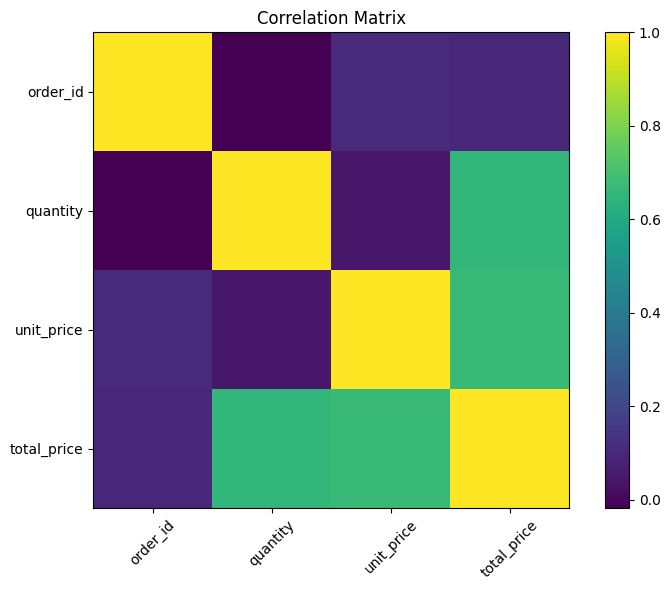

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.imshow(correlation_matrix, interpolation="none")

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()